# Churn Prediction Model: Optimisation and Explainability

## 1. Initial Setup and Library Imports

In [ ]:
!pip install shap
!pip install lime
!pip install imblearn
!pip install xgboost
!pip install aif360
!pip install fairlearn
!pip install 'aif360[inFairness]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=06aa379fc93f8a6a77018b4decb716c2b929dd49faf7800dcced682f757cc61e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.6 MB/s eta 0:00:00


In [ ]:
import warnings
# Suppress harmless scikit-learn warnings for a cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import lime
import lime.lime_tabular
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from sklearn.neural_network import MLPClassifier


/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

## 2. Data Loading and Initial Overview

In [ ]:
# 1. Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# 2. Define the path to your specific AIMI.xlsx file
file_path = '/content/drive/MyDrive/Colab Notebooks/AIMI.xlsx'

# 3. Load the Excel dataset into a Pandas DataFrame
df = pd.read_excel(file_path)

# Check if the DataFrame is empty after loading
if df.empty:
    raise ValueError("The Excel file 'AIMI.xlsx' appears to be empty or could not be read. Please check the file's content and ensure it has data.")

# 4. Drop the irrelevant customerID column
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully. Here are the first 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning, Feature Engineering, and Encoding

In [ ]:
# Ensure df is not empty before proceeding
if df.empty:
    raise ValueError("DataFrame 'df' is empty. Please ensure cell 91adfa33 (Data Loading) was executed successfully and df is populated.")

#Zero-Imputation for MNAR TotalCharges (needed for AvgMonthlyCharge calculation)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

#Feature Engineering: Average Monthly Charge
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

#Feature Engineering: Charge_Delta (captures monthly charge fluctuations)
df['Charge_Delta'] = df['MonthlyCharges'] - df['AvgMonthlyCharge']


print(f"Unique values in 'Churn' column before any string processing: {df['Churn'].unique()}")


# 4. Binary target mapping

df['Churn'] = df['Churn'].astype(str).str.lower().str.strip()


print(f"Unique values in 'Churn' column after lowercasing and stripping: {df['Churn'].unique()}")


df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})

# Remove rows where 'Churn' is NaN after mapping (i.e., values that were neither 'yes' nor 'no')
df.dropna(subset=['Churn'], inplace=True)


print(f"Unique values in 'InternetService' column before mapping: {df['InternetService'].unique()}")


#Ordinal mapping for 'InternetService'
df['InternetService'] = df['InternetService'].astype(str).str.lower().str.strip()
internet_service_mapping = {
    'no': 0,
    'dsl': 1,
    'fiber optic': 2
}
df['InternetService'] = df['InternetService'].map(internet_service_mapping)

# Check for any unmapped values (NaNs)
if df['InternetService'].isnull().any():
    print("Warning: Some 'InternetService' values were not mapped. Check original unique values and the mapping.")


print(f"Unique values in 'InternetService' column after ordinal mapping: {df['InternetService'].unique()}")


# 6. Prepare features (X) and target (y)
# Drop original 'MonthlyCharges' and 'TotalCharges' to address ovelap
features_to_drop = ['Churn', 'MonthlyCharges', 'TotalCharges']
#only drop columns that actually exist in the DataFrame
existing_features_to_drop = [col for col in features_to_drop if col in df.columns]

X = pd.get_dummies(df.drop(existing_features_to_drop, axis=1), drop_first=True)
y = df['Churn']

print("Data cleaning, feature engineering, and encoding complete. X and y are prepared.")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Unique values in 'Churn' column before any string processing: ['No' 'Yes']
Unique values in 'Churn' column after lowercasing and stripping: ['no' 'yes']
Unique values in 'InternetService' column before mapping: ['DSL' 'Fiber optic' 'No']
Unique values in 'InternetService' column after ordinal mapping: [1 2 0]
Data cleaning, feature engineering, and encoding complete. X and y are prepared.
Shape of X: (7043, 29), Shape of y: (7043,)


## 4. Train-Test Split and Scaling for Baseline Model

In [ ]:
# Train-Test Split (80:20 validation fold)
# Store unscaled versions for later use with pipelines that include scalers
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Z-score Normalisation for continuous variables (for baseline models)
continuous_cols = ['tenure', 'AvgMonthlyCharge', 'Charge_Delta']
scaler = StandardScaler()
X_train_scaled = X_train_unscaled.copy()
X_test_scaled = X_test_unscaled.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_scaled[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test_scaled[continuous_cols])

print("Train-test split and scaling for baseline models complete.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}, Shape of X_test_scaled: {X_test_scaled.shape}")

Train-test split and scaling for baseline models complete.
Shape of X_train_scaled: (5634, 29), Shape of X_test_scaled: (1409, 29)


## 5. Baseline Logistic Regression (Untuned)

In [ ]:
# Apply SMOTE to the baseline training data
smote_baseline = SMOTE(random_state=42)
X_train_baseline_resampled, y_train_baseline_resampled = smote_baseline.fit_resample(X_train_scaled, y_train)

# Logistic Regression model
untuned_lr_model = LogisticRegression(max_iter=1000, random_state=42)
untuned_lr_model.fit(X_train_baseline_resampled, y_train_baseline_resampled)

# Evaluate the untuned model
y_pred_baseline = untuned_lr_model.predict(X_test_scaled)
y_pred_proba_baseline = untuned_lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Untuned Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_baseline):.3f}")


--- Untuned Logistic Regression Model Evaluation ---
Accuracy: 0.735
Precision: 0.500
Recall: 0.717
F1-Score: 0.589
ROC-AUC: 0.825


## 6. Cross-Validation and Hyperparameter Tuning for Logistic Regression

In [ ]:
print("\n--- 5-Fold Cross-Validation for Logistic Regression ---")

X_cv = X.copy()
y_cv = y.copy()

pipeline_lr_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores_cv = []
precision_scores_cv = []
recall_scores_cv = []
f1_scores_cv = []
roc_auc_scores_cv = []

for fold, (train_index, test_index) in enumerate(kf.split(X_cv, y_cv)):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    print(f"\n--- Fold {fold+1} ---")
    # Fit the pipeline on the training fold
    pipeline_lr_cv.fit(X_train_fold, y_train_fold)

    # Predict on the test fold
    y_pred_fold = pipeline_lr_cv.predict(X_test_fold)
    y_pred_proba_fold = pipeline_lr_cv.predict_proba(X_test_fold)[:, 1]

    accuracy_scores_cv.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores_cv.append(precision_score(y_test_fold, y_pred_fold))
    recall_scores_cv.append(recall_score(y_test_fold, y_pred_fold))
    f1_scores_cv.append(f1_score(y_test_fold, y_pred_fold))
    roc_auc_scores_cv.append(roc_auc_score(y_test_fold, y_pred_proba_fold))

print("\n--- Cross-Validation Average Metrics ---")
print(f"Average Accuracy: {np.mean(accuracy_scores_cv):.3f}")
print(f"Average Precision: {np.mean(precision_scores_cv):.3f}")
print(f"Average Recall: {np.mean(recall_scores_cv):.3f}")
print(f"Average F1-Score: {np.mean(f1_scores_cv):.3f}")
print(f"Average ROC-AUC: {np.mean(roc_auc_scores_cv):.3f}")


--- 5-Fold Cross-Validation for Logistic Regression ---

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Cross-Validation Average Metrics ---
Average Accuracy: 0.758
Average Precision: 0.530
Average Recall: 0.773
Average F1-Score: 0.629
Average ROC-AUC: 0.846


In [ ]:
print("\n--- Demonstrating Hyperparameter Search for Logistic Regression ---")

# search for the best hyperparameters

# Define the parameter grid to search
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'smote__sampling_strategy': ['minority', 0.5, 0.75, 1.0]
}

# Initialise GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_lr_cv,
    param_grid=param_grid,
    cv=kf,
    scoring='roc_auc', # Optimise for ROC-AUC score
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on the full pre-processed data (X_cv, y_cv)
grid_search.fit(X_cv, y_cv)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best ROC-AUC score found: {grid_search.best_score_:.3f}")

# Extract the best estimator (which is the entire pipeline)
optimised_lr_model = grid_search.best_estimator_


--- Demonstrating Hyperparameter Search for Logistic Regression ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters found: {'classifier__C': 0.1, 'smote__sampling_strategy': 0.5}
Best ROC-AUC score found: 0.846


## 7. Optimised Logistic Regression Model Evaluation

In [ ]:
# Evaluate the optimised model on the test set
y_pred_optimised = optimised_lr_model.predict(X_test_unscaled)
y_pred_proba_optimised = optimised_lr_model.predict_proba(X_test_unscaled)[:, 1]

print("\n--- Optimised Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimised):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_optimised):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_optimised):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_optimised):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_optimised):.3f}")


--- Optimised Logistic Regression Model Evaluation ---
Accuracy: 0.788
Precision: 0.594
Recall: 0.634
F1-Score: 0.613
ROC-AUC: 0.847


## 8. Comparison of Untuned vs. Optimised Logistic Regression

In [ ]:
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Untuned LR': [
        accuracy_score(y_test, untuned_lr_model.predict(X_test_scaled)),
        precision_score(y_test, untuned_lr_model.predict(X_test_scaled)),
        recall_score(y_test, untuned_lr_model.predict(X_test_scaled)),
        f1_score(y_test, untuned_lr_model.predict(X_test_scaled)),
        roc_auc_score(y_test, untuned_lr_model.predict_proba(X_test_scaled)[:, 1])
    ],
    'Optimised LR': [
        accuracy_score(y_test, optimised_lr_model.predict(X_test_unscaled)),
        precision_score(y_test, optimised_lr_model.predict(X_test_unscaled)),
        recall_score(y_test, optimised_lr_model.predict(X_test_unscaled)),
        f1_score(y_test, optimised_lr_model.predict(X_test_unscaled)),
        roc_auc_score(y_test, optimised_lr_model.predict_proba(X_test_unscaled)[:, 1])
    ]
})

print("\n--- Model Performance Comparison ---")
display(results_df.round(3))


--- Model Performance Comparison ---


,Metric,Untuned LR,Optimised LR
0,Accuracy,0.735,0.788
1,Precision,0.500,0.594
2,Recall,0.717,0.634
3,F1-Score,0.589,0.613
4,ROC-AUC,0.825,0.847


## 9. Optimised XGBoost Model with  Random Forest Model with  Cross-Validation and Hyperparameter Tuning

In [ ]:

print("\n--- Demonstrating Hyperparameter Search for Random Forest ---")

pipeline_rf_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'smote__sampling_strategy': ['minority', 0.5]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf_cv,
    param_grid=param_grid_rf,
    cv=kf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Fitting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_cv, y_cv)

print(f"Best Parameters for Random Forest: {grid_search_rf.best_params_}")
optimised_rf_model = grid_search_rf.best_estimator_


--- Demonstrating Hyperparameter Search for Random Forest ---
Fitting GridSearchCV for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100, 'smote__sampling_strategy': 'minority'}


In [ ]:
from sklearn.pipeline import Pipeline

print("\n--- Optimising XGBoost Configuration ---")

# Calculate scale_pos_weight for imbalance handling
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# A broader grid search focusing on tree complexity and learning rate
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_child_weight': [1, 3, 5], # Higher values stop the model from learning highly specific edge cases
    'classifier__subsample': [0.8],
    'classifier__colsample_bytree': [0.8]
}
# Switched scoring to 'f1' to better balance precision and recall
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=kf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Fitting Refined XGBoost...")
grid_search_xgb.fit(X_cv, y_cv)

print(f"Best Parameters for XGBoost: {grid_search_xgb.best_params_}")
optimised_xgb_model = grid_search_xgb.best_estimator_


--- Optimising XGBoost Configuration ---
Fitting Refined XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for XGBoost: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


# 10. Optimised Random Forest and XGBoost Model Evaluation

In [ ]:
updated_results_df = results_df.copy()

updated_results_df['Optimised RF'] = [
    accuracy_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    precision_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    recall_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    f1_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    roc_auc_score(y_test, optimised_rf_model.predict_proba(X_test_unscaled)[:, 1])
]

In [ ]:
# Evaluation
y_pred_xgb_optimised = optimised_xgb_model.predict(X_test_unscaled)
y_pred_proba_xgb_optimised = optimised_xgb_model.predict_proba(X_test_unscaled)[:, 1]

print("\n--- Refined XGBoost Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_optimised):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_optimised):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_optimised):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_optimised):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_optimised):.3f}")


--- Refined XGBoost Model Evaluation ---
Accuracy: 0.762
Precision: 0.535
Recall: 0.807
F1-Score: 0.643
ROC-AUC: 0.869


# 11. Updated Model Performance Comparison

In [ ]:

updated_results_df = results_df.copy()
updated_results_df['Optimised XGBoost'] = [
    accuracy_score(y_test, y_pred_xgb_optimised),
    precision_score(y_test, y_pred_xgb_optimised),
    recall_score(y_test, y_pred_xgb_optimised),
    f1_score(y_test, y_pred_xgb_optimised),
    roc_auc_score(y_test, y_pred_proba_xgb_optimised)
]

print("\n--- Updated Performance Table with Refined XGBoost ---")
display(updated_results_df.round(3))


--- Updated Performance Table with Refined XGBoost ---


,Metric,Untuned LR,Optimised LR,Optimised XGBoost
0,Accuracy,0.735,0.788,0.762
1,Precision,0.500,0.594,0.535
2,Recall,0.717,0.634,0.807
3,F1-Score,0.589,0.613,0.643
4,ROC-AUC,0.825,0.847,0.869


In [ ]:
# Update results with Optimised Random Forest
updated_results_df['Optimised RF'] = [
    accuracy_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    precision_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    recall_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    f1_score(y_test, optimised_rf_model.predict(X_test_unscaled)),
    roc_auc_score(y_test, optimised_rf_model.predict_proba(X_test_unscaled)[:, 1])
]

print("\n--- Model Performance Comparison (Including RF) ---")
display(updated_results_df.round(3))


--- Model Performance Comparison (Including RF) ---


,Metric,Untuned LR,Optimised LR,Optimised XGBoost,Optimised RF
0,Accuracy,0.735,0.788,0.762,0.817
1,Precision,0.500,0.594,0.535,0.617
2,Recall,0.717,0.634,0.807,0.818
3,F1-Score,0.589,0.613,0.643,0.703
4,ROC-AUC,0.825,0.847,0.869,0.909


# 12. Explainable AI (SHAP and LIME) for Optimised XGBoost Model


Generating SHAP Summary Plot for Optimised XGBoost...


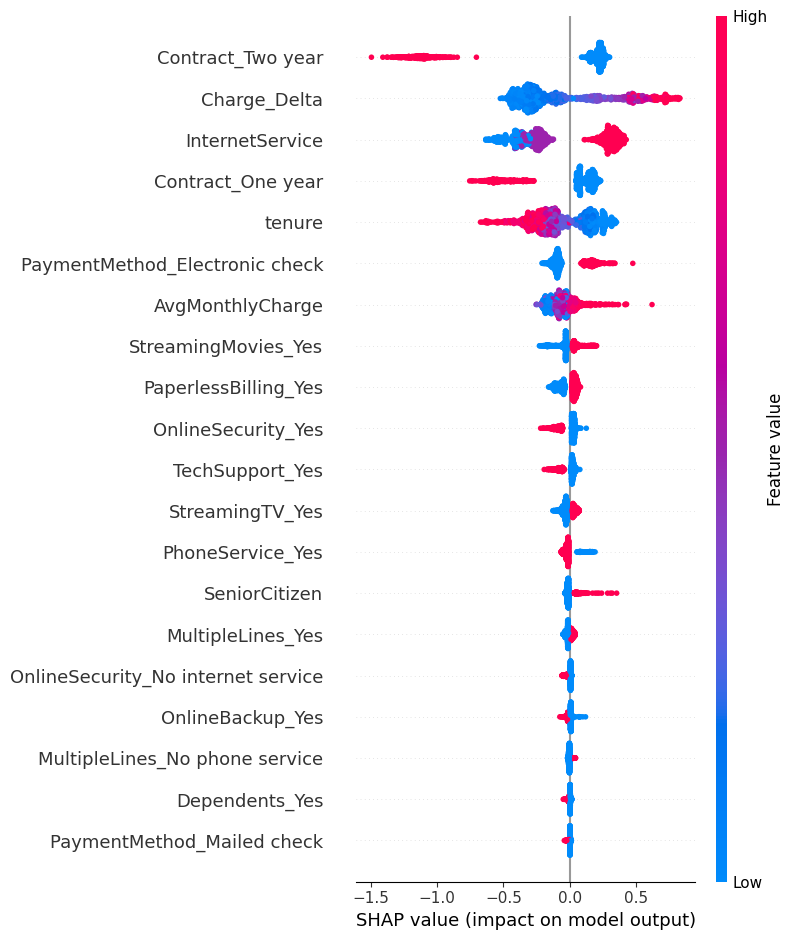


Generating LIME Local Explanation for Optimised XGBoost...

LIME explanation for customer at index 10 in X_test_unscaled:


In [ ]:
print("\nGenerating SHAP Summary Plot for Optimised XGBoost...")
# SHAP Global Explainability for Optimised XGBoost

fitted_scaler_xgb = optimised_xgb_model.named_steps['scaler']
fitted_classifier_xgb = optimised_xgb_model.named_steps['classifier']

# Use TreeExplainer for XGBoost
explainer_shap_xgb_optimised = shap.TreeExplainer(fitted_classifier_xgb)

# Compute SHAP values on the scaled test data
shap_values_xgb_optimised = explainer_shap_xgb_optimised.shap_values(fitted_scaler_xgb.transform(X_test_unscaled))

# Plot the SHAP summary
shap.summary_plot(shap_values_xgb_optimised, fitted_scaler_xgb.transform(X_test_unscaled), feature_names=X_test_unscaled.columns)

print("\nGenerating LIME Local Explanation for Optimised XGBoost...")
# LIME Local Explainability
explainer_lime_xgb_optimised = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_unscaled.values,
    feature_names=X_train_unscaled.columns,
    class_names=['Retained', 'Churned'],
    mode='classification'
)

customer_idx_lime_xgb = 10
predict_fn_xgb_optimised = optimised_xgb_model.predict_proba

exp_xgb_optimised = explainer_lime_xgb_optimised.explain_instance(
    data_row=X_test_unscaled.iloc[customer_idx_lime_xgb].values,
    predict_fn=predict_fn_xgb_optimised,
    num_features=10
)

print(f"\nLIME explanation for customer at index {customer_idx_lime_xgb} in X_test_unscaled:")
exp_xgb_optimised.show_in_notebook(show_table=True, show_all=False)

In [ ]:
print(f"\nPrediction probabilities for customer {customer_idx_lime_xgb} (Retained, Churned):")
print(predict_fn_xgb_optimised(X_test_unscaled.iloc[customer_idx_lime_xgb].values.reshape(1, -1)))


Prediction probabilities for customer 10 (Retained, Churned):
[[0.4873755 0.5126245]]


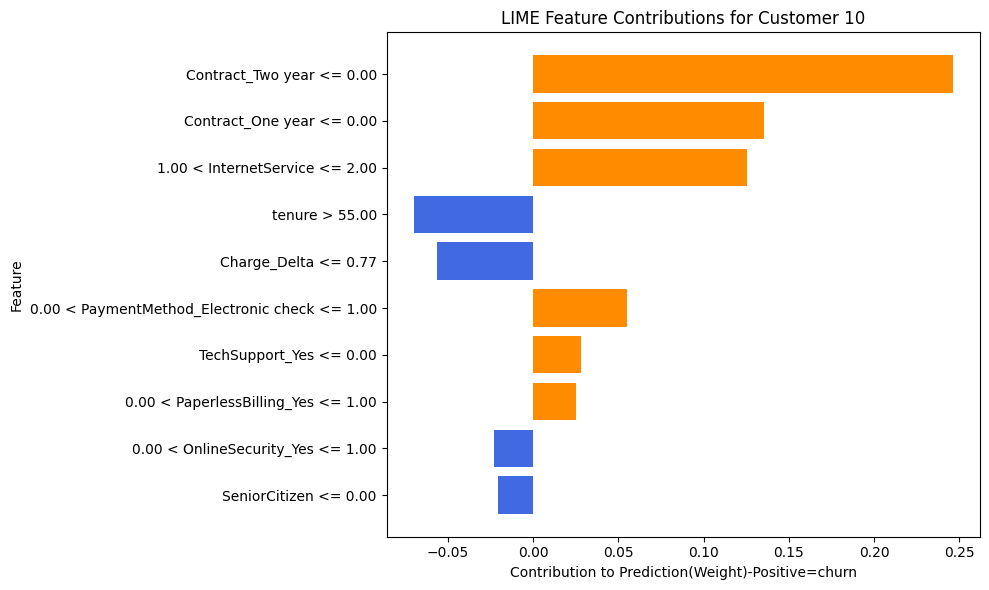

In [ ]:


# Get the explanation as a list of (feature, weight) tuples
lime_explanation_list = exp_xgb_optimised.as_list()

# Separate features and weights
features = [item[0] for item in lime_explanation_list]
weights = [item[1] for item in lime_explanation_list]

# Sort by absolute weight for better visualisation
sorted_indices = np.argsort(np.abs(weights))
features_sorted = [features[i] for i in sorted_indices]
weights_sorted = [weights[i] for i in sorted_indices]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.barh(features_sorted, weights_sorted, color=['royalblue' if w < 0 else 'darkorange' for w in weights_sorted])
plt.xlabel('Contribution to Prediction(Weight)-Positive=churn')
plt.ylabel('Feature')
plt.title(f'LIME Feature Contributions for Customer {customer_idx_lime_xgb}')
plt.tight_layout()
plt.show()

#13. Fairness Evaluation (AIF360) for Optimised XGBoost

In [21]:



print("\n--- Preparing Data for AIF360 Fairness Evaluation ---")

# Privileged - is a tag just for the maths to work

# Create DataFrame for True Labels
test_df_true = X_test_unscaled.copy()
test_df_true['Churn'] = y_test

dataset_true = BinaryLabelDataset(
    df=test_df_true,
    label_names=['Churn'],
    protected_attribute_names=['SeniorCitizen'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

# Create DataFrame for Predicted Labels from Optimised XGBoost
test_df_pred = X_test_unscaled.copy()
test_df_pred['Churn'] = y_pred_xgb_optimised

dataset_pred = BinaryLabelDataset(
    df=test_df_pred,
    label_names=['Churn'],
    protected_attribute_names=['SeniorCitizen'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

# Define groups
privileged_groups = [{'SeniorCitizen': 0}]
unprivileged_groups = [{'SeniorCitizen': 1}]

# Calculate Metrics
metric_xgb = ClassificationMetric(
    dataset_true, dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("\n--- AIF360 Fairness Metrics for Optimised XGBoost ---")
print(f"Protected Attribute: 'SeniorCitizen'")
print(f"Favorable Outcome: Retained (Churn=0)\n")

print(f"Disparate Impact: {metric_xgb.disparate_impact():.3f} (Ideal: 1.0, < 1 indicates bias against unprivileged)")
print(f"Statistical Parity Difference: {metric_xgb.statistical_parity_difference():.3f} (Ideal: 0.0)")
print(f"Equal Opportunity Difference (True Positive Rate Difference): {metric_xgb.equal_opportunity_difference():.3f} (Ideal: 0.0)")
print(f"Average Odds Difference: {metric_xgb.average_odds_difference():.3f} (Ideal: 0.0)")
print("\n--- AIF360 Fairness Metrics for Gender (gender_Male) ---")
print("Privileged=1 (Male), Unprivileged=0 (Female)")

dataset_true_gender = BinaryLabelDataset(
    df=test_df_true,
    label_names=['Churn'],
    protected_attribute_names=['gender_Male'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

dataset_pred_gender = BinaryLabelDataset(
    df=test_df_pred,
    label_names=['Churn'],
    protected_attribute_names=['gender_Male'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

metric_gender = ClassificationMetric(
    dataset_true_gender, dataset_pred_gender,
    unprivileged_groups=[{'gender_Male': 0}],
    privileged_groups=[{'gender_Male': 1}]
)

print(f"Disparate Impact: {metric_gender.disparate_impact():.3f}")
print(f"Statistical Parity Difference: {metric_gender.statistical_parity_difference():.3f}")
print(f"Equal Opportunity Difference: {metric_gender.equal_opportunity_difference():.3f}")
print(f"Average Odds Difference: {metric_gender.average_odds_difference():.3f}")


print("\n--- AIF360 Fairness Metrics for Partner (Partner_Yes) ---")
print("Privileged=1 (Has Partner), Unprivileged=0 (No Partner)")

dataset_true_partner = BinaryLabelDataset(
    df=test_df_true,
    label_names=['Churn'],
    protected_attribute_names=['Partner_Yes'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

dataset_pred_partner = BinaryLabelDataset(
    df=test_df_pred,
    label_names=['Churn'],
    protected_attribute_names=['Partner_Yes'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

metric_partner = ClassificationMetric(
    dataset_true_partner, dataset_pred_partner,
    unprivileged_groups=[{'Partner_Yes': 0}],
    privileged_groups=[{'Partner_Yes': 1}]
)

print(f"Disparate Impact: {metric_partner.disparate_impact():.3f}")
print(f"Statistical Parity Difference: {metric_partner.statistical_parity_difference():.3f}")
print(f"Equal Opportunity Difference: {metric_partner.equal_opportunity_difference():.3f}")
print(f"Average Odds Difference: {metric_partner.average_odds_difference():.3f}")


print("\n--- AIF360 Fairness Metrics for Dependents (Dependents_Yes) ---")
print("Privileged=1 (Has Dependents), Unprivileged=0 (No Dependents)")

dataset_true_dep = BinaryLabelDataset(
    df=test_df_true,
    label_names=['Churn'],
    protected_attribute_names=['Dependents_Yes'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

dataset_pred_dep = BinaryLabelDataset(
    df=test_df_pred,
    label_names=['Churn'],
    protected_attribute_names=['Dependents_Yes'],
    favorable_label=0.0,
    unfavorable_label=1.0
)

metric_dep = ClassificationMetric(
    dataset_true_dep, dataset_pred_dep,
    unprivileged_groups=[{'Dependents_Yes': 0}],
    privileged_groups=[{'Dependents_Yes': 1}]
)

print(f"Disparate Impact: {metric_dep.disparate_impact():.3f}")
print(f"Statistical Parity Difference: {metric_dep.statistical_parity_difference():.3f}")
print(f"Equal Opportunity Difference: {metric_dep.equal_opportunity_difference():.3f}")
print(f"Average Odds Difference: {metric_dep.average_odds_difference():.3f}")



--- Preparing Data for AIF360 Fairness Evaluation ---

--- AIF360 Fairness Metrics for Optimised XGBoost ---
Protected Attribute: 'SeniorCitizen'
Favorable Outcome: Retained (Churn=0)

Disparate Impact: 0.537 (Ideal: 1.0, < 1 indicates bias against unprivileged)
Statistical Parity Difference: -0.299 (Ideal: 0.0)
Equal Opportunity Difference (True Positive Rate Difference): -0.215 (Ideal: 0.0)
Average Odds Difference: -0.183 (Ideal: 0.0)

--- AIF360 Fairness Metrics for Gender (gender_Male) ---
Privileged=1 (Male), Unprivileged=0 (Female)
Disparate Impact: 1.012
Statistical Parity Difference: 0.007
Equal Opportunity Difference: 0.018
Average Odds Difference: 0.029

--- AIF360 Fairness Metrics for Partner (Partner_Yes) ---
Privileged=1 (Has Partner), Unprivileged=0 (No Partner)
Disparate Impact: 0.638
Statistical Parity Difference: -0.267
Equal Opportunity Difference: -0.202
Average Odds Difference: -0.177

--- AIF360 Fairness Metrics for Dependents (Dependents_Yes) ---
Privileged=1 (Ha

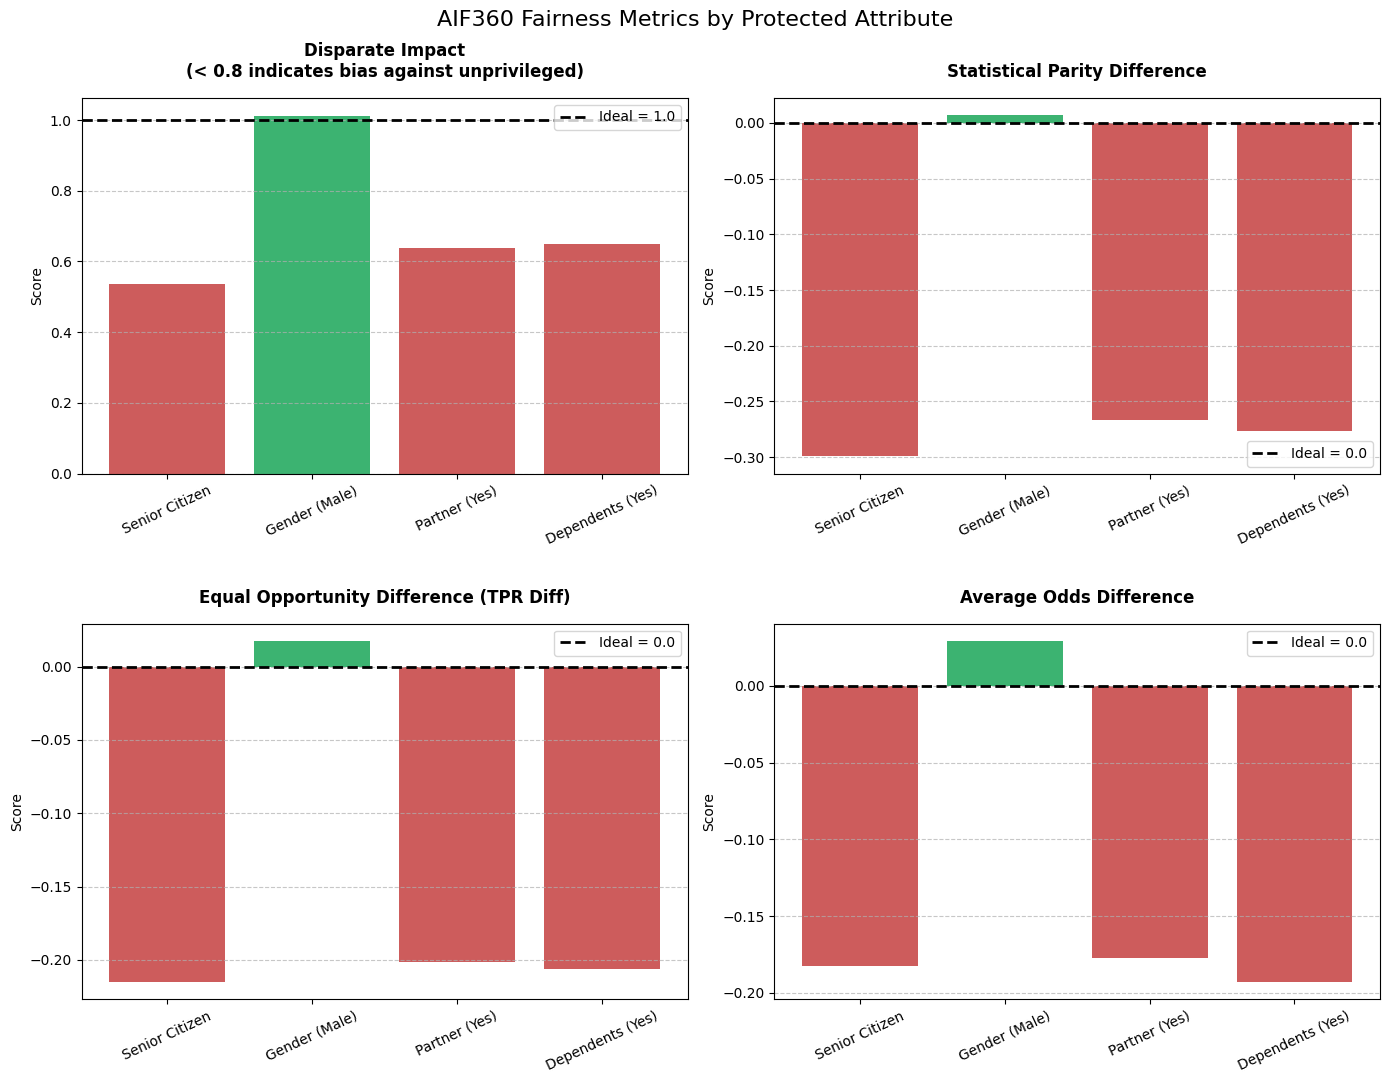

In [22]:


metrics_data = {
    'Senior Citizen': {
        'Disparate Impact': metric_xgb.disparate_impact(),
        'Statistical Parity': metric_xgb.statistical_parity_difference(),
        'Equal Opportunity': metric_xgb.equal_opportunity_difference(),
        'Average Odds': metric_xgb.average_odds_difference()
    },
    'Gender (Male)': {
        'Disparate Impact': metric_gender.disparate_impact(),
        'Statistical Parity': metric_gender.statistical_parity_difference(),
        'Equal Opportunity': metric_gender.equal_opportunity_difference(),
        'Average Odds': metric_gender.average_odds_difference()
    },
    'Partner (Yes)': {
        'Disparate Impact': metric_partner.disparate_impact(),
        'Statistical Parity': metric_partner.statistical_parity_difference(),
        'Equal Opportunity': metric_partner.equal_opportunity_difference(),
        'Average Odds': metric_partner.average_odds_difference()
    },
    'Dependents (Yes)': {
        'Disparate Impact': metric_dep.disparate_impact(),
        'Statistical Parity': metric_dep.statistical_parity_difference(),
        'Equal Opportunity': metric_dep.equal_opportunity_difference(),
        'Average Odds': metric_dep.average_odds_difference()
    }
}

# Convert to DataFrame for easy plotting
df_metrics = pd.DataFrame(metrics_data).T

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('AIF360 Fairness Metrics by Protected Attribute', fontsize=16)

# Helper function to plot each metric
def plot_metric(ax, metric_name, ideal_val, title):
    values = df_metrics[metric_name]

    # Colour logic: Green if close to ideal, else Red
    if metric_name == 'Disparate Impact':
         colors = ['mediumseagreen' if 0.8 <= v <= 1.25 else 'indianred' for v in values]
    else:
         colors = ['mediumseagreen' if abs(v - ideal_val) <= 0.1 else 'indianred' for v in values]

    bars = ax.bar(df_metrics.index, values, color=colors)
    ax.axhline(y=ideal_val, color='black', linestyle='--', linewidth=2, label=f'Ideal = {ideal_val}')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('Score')
    ax.legend()
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', linestyle='--', alpha=0.7)


# Generate the 4 subplots
plot_metric(axes[0, 0], 'Disparate Impact', 1.0, 'Disparate Impact\n(< 0.8 indicates bias against unprivileged)')
plot_metric(axes[0, 1], 'Statistical Parity', 0.0, 'Statistical Parity Difference')
plot_metric(axes[1, 0], 'Equal Opportunity', 0.0, 'Equal Opportunity Difference (TPR Diff)')
plot_metric(axes[1, 1], 'Average Odds', 0.0, 'Average Odds Difference')

plt.tight_layout()
fig.subplots_adjust(top=0.90, hspace=0.4)
plt.show()


#14. Neural Network (MLP) Comparison


In [23]:


print("--- Training Neural Network (MLP) ---")

# Define the MLP Pipeline
mlp_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32),
                                 max_iter=500,
                                 random_state=42,
                                 early_stopping=True))
])

# Fit the model
mlp_pipeline.fit(X_train_unscaled, y_train)

# Evaluate
y_pred_mlp = mlp_pipeline.predict(X_test_unscaled)
y_pred_proba_mlp = mlp_pipeline.predict_proba(X_test_unscaled)[:, 1]

# Add to comparison dataframe
updated_results_df['Neural Network (MLP)'] = [
    accuracy_score(y_test, y_pred_mlp),
    precision_score(y_test, y_pred_mlp),
    recall_score(y_test, y_pred_mlp),
    f1_score(y_test, y_pred_mlp),
    roc_auc_score(y_test, y_pred_proba_mlp)
]

print("MLP Training Complete. Updated Comparison Table:")
display(updated_results_df.round(3))

--- Training Neural Network (MLP) ---
MLP Training Complete. Updated Comparison Table:


,Metric,Untuned LR,Optimised LR,Optimised XGBoost,Optimised RF,Neural Network (MLP)
0,Accuracy,0.735,0.788,0.762,0.817,0.789
1,Precision,0.500,0.594,0.535,0.617,0.596
2,Recall,0.717,0.634,0.807,0.818,0.636
3,F1-Score,0.589,0.613,0.643,0.703,0.616
4,ROC-AUC,0.825,0.847,0.869,0.909,0.842


In [24]:


print("--- Optimizing Neural Network (MLP) ---")

# Define a more granular grid for the MLP
mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(100,), (64, 32), (50, 50, 50)],
    'classifier__alpha': [0.0001, 0.05],
    'classifier__learning_rate_init': [0.001, 0.01],
    'smote__sampling_strategy': [0.5, 0.8]
}

mlp_grid_search = GridSearchCV(
    mlp_pipeline,
    mlp_param_grid,
    cv=kf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

mlp_grid_search.fit(X_cv, y_cv)

print(f"Best MLP Parameters: {mlp_grid_search.best_params_}")
optimised_mlp_model = mlp_grid_search.best_estimator_

# Update results
y_pred_proba_mlp_opt = optimised_mlp_model.predict_proba(X_test_unscaled)[:, 1]
y_pred_mlp_opt = optimised_mlp_model.predict(X_test_unscaled)

updated_results_df['Optimised MLP'] = [
    accuracy_score(y_test, y_pred_mlp_opt),
    precision_score(y_test, y_pred_mlp_opt),
    recall_score(y_test, y_pred_mlp_opt),
    f1_score(y_test, y_pred_mlp_opt),
    roc_auc_score(y_test, y_pred_proba_mlp_opt)
]

print("\n--- Final Model Performance Comparison Table ---")
display(updated_results_df.round(3))

--- Optimizing Neural Network (MLP) ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best MLP Parameters: {'classifier__alpha': 0.05, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate_init': 0.001, 'smote__sampling_strategy': 0.5}

--- Final Model Performance Comparison Table ---


,Metric,Untuned LR,Optimised LR,Optimised XGBoost,Optimised RF,Neural Network (MLP),Optimised MLP
0,Accuracy,0.735,0.788,0.762,0.817,0.789,0.804
1,Precision,0.500,0.594,0.535,0.617,0.596,0.641
2,Recall,0.717,0.634,0.807,0.818,0.636,0.596
3,F1-Score,0.589,0.613,0.643,0.703,0.616,0.618
4,ROC-AUC,0.825,0.847,0.869,0.909,0.842,0.850


In [25]:
from sklearn.ensemble import VotingClassifier

#create and fit Voting Ensemble with refined XGBoost and MLP
voting_clf = VotingClassifier(
    estimators=[
        ('lr', optimised_lr_model),
        ('rf', optimised_rf_model),
        ('xgb', optimised_xgb_model),
        ('mlp', optimised_mlp_model)
    ],
    voting='soft'
)

print("fitting Soft-Voting Ensemble with refined XGBoost and MLP...")
voting_clf.fit(X_train_unscaled, y_train)

# Evaluation
y_pred_voting = voting_clf.predict(X_test_unscaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_unscaled)[:, 1]

# Update comparison table
updated_results_df['Voting Ensemble'] = [
    accuracy_score(y_test, y_pred_voting),
    precision_score(y_test, y_pred_voting),
    recall_score(y_test, y_pred_voting),
    f1_score(y_test, y_pred_voting),
    roc_auc_score(y_test, y_pred_proba_voting)
]

print(f"\nUpdated Voting Ensemble ROC-AUC: {roc_auc_score(y_test, y_pred_proba_voting):.3f}")

fitting Soft-Voting Ensemble with refined XGBoost and MLP...

Updated Voting Ensemble ROC-AUC: 0.848


# Final Model Performance Comparison (All Models and Ensembles)

In [26]:
display(updated_results_df.round(3))

,Metric,Untuned LR,Optimised LR,Optimised XGBoost,Optimised RF,Neural Network (MLP),Optimised MLP,Voting Ensemble
0,Accuracy,0.735,0.788,0.762,0.817,0.789,0.804,0.779
1,Precision,0.500,0.594,0.535,0.617,0.596,0.641,0.569
2,Recall,0.717,0.634,0.807,0.818,0.636,0.596,0.695
3,F1-Score,0.589,0.613,0.643,0.703,0.616,0.618,0.626
4,ROC-AUC,0.825,0.847,0.869,0.909,0.842,0.850,0.848
